# Классификация эмоций: Нейтральная vs Ненейтральная

Сравниваем три подхода на объединённом датасете **RAVDESS + CREMA-D**:
1. **DistilHuBERT → Linear Classifier** — обучение с предобученным аудио-энкодером
2. **Log-Mel Spectrogram → CNN** — 2D-свёрточная сеть на спектрограммах
3. **MFCC → SVM** — классический ML-подход

Метрики сравнения:
- **Качество** — Accuracy, F1 (macro), Precision, Recall
- **Скорость** — время инференса на одном файле (end-to-end)
- **Размер модели** — объём классификатора и всего пайплайна

In [35]:
import os, io, pickle, time, gc

import librosa
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from transformers import AutoModel, Wav2Vec2FeatureExtractor

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, classification_report,
)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

results = []


def pytorch_size_mb(model):
    b = sum(p.numel() * p.element_size() for p in model.parameters())
    b += sum(x.numel() * x.element_size() for x in model.buffers())
    return b / 1024 ** 2


def sklearn_size_mb(model):
    buf = io.BytesIO()
    pickle.dump(model, buf)
    return buf.tell() / 1024 ** 2

Device: mps


## Загрузка данных RAVDESS + CREMA-D

In [36]:
RAVDESS_PATH = "../datasets/orvile/ravdess-dataset/versions/1/"
SAMPLE_RATE_RAVDESS = 48000

file_paths, labels, speakers, sources = [], [], [], []

# ── RAVDESS ──
# Формат: 03-01-{emotion}-01-01-01-{actor}.wav  (emotion ≤ 2 - neutral)
audio_base = os.path.join(RAVDESS_PATH, "Audio_Speech_Actors_01-24")
for actor_dir in sorted(os.listdir(audio_base)):
    if not actor_dir.startswith("Actor_"):
        continue
    for f in sorted(os.listdir(os.path.join(audio_base, actor_dir))):
        if not f.endswith(".wav"):
            continue
        fp = os.path.join(audio_base, actor_dir, f)
        emotion = int(os.path.basename(f).split('-')[2])
        file_paths.append(fp)
        # 01 = neutral, 02 = calm, 03 = happy, 04 = sad, 05 = angry, 06 = fearful, 07 = disgust, 08 = surprised
        labels.append(0 if emotion <= 2 else 1)
        speakers.append(f"rav_{actor_dir.split('_')[1]}")
        sources.append("RAVDESS")

n_rav = len(file_paths)
print("RAVDESS: ", n_rav)

RAVDESS:  1440


In [37]:
CREMA_PATH = "../datasets/crema-d/"
SAMPLE_RATE_CREMAD = 16000
SR = SAMPLE_RATE_CREMAD # will be used as default

# ── CREMA-D ──
# Формат: {actorID}_{sentence}_{EMO}_{intensity}.wav  (NEU - neutral)
for f in sorted(os.listdir(CREMA_PATH)):
    if not f.endswith(".wav"):
        continue
    fp = os.path.join(CREMA_PATH, f)
    parts = f.replace(".wav", "").split("_")
    file_paths.append(fp)
    labels.append(0 if parts[2] == "NEU" else 1)
    speakers.append(f"crm_{parts[0]}")
    sources.append("CREMA-D")

n_crm = len(file_paths) - n_rav

labels = np.array(labels)
speakers = np.array(speakers)
sources = np.array(sources)

print("CREMA-D: ", n_crm)

CREMA-D:  7442


In [38]:
# Speaker-independent split: по 20 % спикеров из каждого датасета - test
test_speakers = set()
for ds in ["RAVDESS", "CREMA-D"]:
    ds_spk = sorted(set(speakers[sources == ds]))
    n_test = max(1, len(ds_spk) // 5)
    test_speakers.update(ds_spk[-n_test:])

train_idx = [i for i, s in enumerate(speakers) if s not in test_speakers]
test_idx  = [i for i, s in enumerate(speakers) if s in test_speakers]

train_files = [file_paths[i] for i in train_idx]
test_files  = [file_paths[i] for i in test_idx]
y_train, y_test = labels[train_idx], labels[test_idx]

print(f"RAVDESS: {n_rav} файлов | CREMA-D: {n_crm} файлов | Всего: {len(file_paths)}")
print(f"Neutral: {(labels==0).sum()} | Emotional: {(labels==1).sum()}")
print(f"\nSpeaker-independent split (20 % спикеров из каждого датасета):")
print(f"  Train: {len(train_files)} файлов ({len(set(speakers[train_idx]))} спикеров)")
print(f"  Test:  {len(test_files)} файлов ({len(test_speakers)} спикеров)")
print(f"  Train balance — neutral: {(y_train==0).sum()}, emotional: {(y_train==1).sum()}")
print(f"  Test  balance — neutral: {(y_test==0).sum()}, emotional: {(y_test==1).sum()}")

RAVDESS: 1440 файлов | CREMA-D: 7442 файлов | Всего: 8882
Neutral: 1375 | Emotional: 7507

Speaker-independent split (20 % спикеров из каждого датасета):
  Train: 7167 файлов (93 спикеров)
  Test:  1715 файлов (22 спикеров)
  Train balance — neutral: 1112, emotional: 6055
  Test  balance — neutral: 263, emotional: 1452


In [44]:
def load_audio(path):
    y, sr = librosa.load(path, sr=None)
    if sr != SR:
        y = librosa.resample(y, orig_sr=sr, target_sr=SR)
    return y

train_files_loaded = [load_audio(f) for f in train_files]
test_files_loaded = [load_audio(f) for f in test_files]


## Подход 1: audio → DistilHuBERT → Linear Classifier

In [69]:
HUBERT_NAME = "ntu-spml/distilhubert"
hub_extractor = Wav2Vec2FeatureExtractor.from_pretrained(HUBERT_NAME)
hub_model = AutoModel.from_pretrained(HUBERT_NAME).to(device).eval()

Loading weights:   0%|          | 0/49 [00:00<?, ?it/s]

In [ ]:
hub_dim = hub_model.config.hidden_size
hub_params = sum(p.numel() for p in hub_model.parameters())
print(f"DistilHuBERT: hidden_size={hub_dim}, params={hub_params:,}")


def hubert_embed(index, train=True):
    file = train_files_loaded[index] if train else test_files_loaded[index]
    inp = hub_extractor(file, sampling_rate=SR, return_tensors="pt").to(device)
    with torch.no_grad():
        h = hub_model(**inp).last_hidden_state  # (1, T, hidden_size)
    if train:
        return h.mean(dim=1).squeeze(0).cpu().numpy()  # (hidden_size,)
    return h.mean(dim=1)

print("Извлечение DistilHuBERT-эмбеддингов...")
start_time = time.time()
X_hub_train = np.array([hubert_embed(index) for index in tqdm(range(len(train_files)))])
extract_time = time.time() - start_time

DistilHuBERT: hidden_size=768, params=23,491,968
Извлечение DistilHuBERT-эмбеддингов...


100%|██████████| 7167/7167 [01:48<00:00, 66.30it/s]


In [ ]:
X_hub_test  = [hubert_embed(index, train=False) for index in tqdm(range(len(test_files)))]
print(f"Train: {X_hub_train.shape}, Test: {len(X_hub_test)}")

100%|██████████| 1715/1715 [00:25<00:00, 67.51it/s]

Train: (7167, 768), Test: 1715


In [74]:
class LinearClassifier(nn.Module):
    def __init__(self, d, n_classes=2):
        super().__init__()
        self.fc = nn.Linear(d, n_classes)

    def forward(self, x):
        return self.fc(x)


model_1 = LinearClassifier(hub_dim).to(device)
opt1 = optim.Adam(model_1.parameters(), lr=1e-3, weight_decay=1e-4)
crit = nn.CrossEntropyLoss()

ds1 = TensorDataset(
    torch.tensor(X_hub_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long),
)
loader1 = DataLoader(ds1, batch_size=32, shuffle=True)

EPOCHS = 200
train_time_1 = 0
t0 = time.time()
for ep in range(EPOCHS):
    model_1.train()
    for xb, yb in loader1:
        xb, yb = xb.to(device), yb.to(device)
        loss = crit(model_1(xb), yb)
        opt1.zero_grad()
        loss.backward()
        opt1.step()
    if (ep + 1) % 10 == 0:
        # we should not measure time of checking accuracy, but only of training
        train_time_1 += time.time() - t0
        t0 = time.time()

        model_1.eval()
        with torch.no_grad():
            acc = (
                model_1(torch.tensor(X_hub_train, dtype=torch.float32).to(device))
                    .argmax(1).cpu().numpy() == y_train
            ).mean()
        print(f"Epoch {ep+1}/{EPOCHS} | Loss {loss.item():.4f} | Train Acc {acc:.4f}")

        # Fast check test accuracy
        preds_1 = []
        for test_index in range(len(test_files)):
            with torch.no_grad():
                emb = X_hub_test[test_index]
                preds_1.append(model_1(emb).argmax(1).item())
        print(f"Test Acc {accuracy_score(y_test, preds_1):.4f}, F1 {f1_score(y_test, preds_1, average='macro'):.4f}")

# End-to-end инференс
model_1.eval()
t0 = time.time()
preds_1 = []
for test_index in tqdm(range(len(test_files))):
    y_audio = test_files_loaded[test_index]
    inp = hub_extractor(y_audio, sampling_rate=SR, return_tensors="pt").to(device)
    with torch.no_grad():
        emb = hub_model(**inp).last_hidden_state.mean(dim=1)
        preds_1.append(model_1(emb).argmax(1).item())
inf_time_1 = (time.time() - t0) / len(test_files)
preds_1 = np.array(preds_1)

hub_pipeline_mb = pytorch_size_mb(hub_model) + pytorch_size_mb(model_1)
cls_1_mb = pytorch_size_mb(model_1)

hub_model.cpu()
model_1.cpu()
del hub_model, hub_extractor
if torch.backends.mps.is_available():
    torch.mps.empty_cache()
gc.collect()

results.append({
    "Модель": "DistilHuBERT + Linear",
    "Accuracy": accuracy_score(y_test, preds_1),
    "F1 (macro)": f1_score(y_test, preds_1, average="macro"),
    "Precision": precision_score(y_test, preds_1, average="macro", zero_division=0),
    "Recall": recall_score(y_test, preds_1, average="macro", zero_division=0),
    "Инференс (мс/файл)": inf_time_1 * 1000,
    "Обучение (сек)": extract_time + train_time_1,
    "Классификатор (MB)": cls_1_mb,
    "Пайплайн (MB)": hub_pipeline_mb,
})
print(f"\nDistilHuBERT + Linear - Acc={results[-1]['Accuracy']:.4f} "
      f"F1={results[-1]['F1 (macro)']:.4f} "
      f"Inf={inf_time_1*1000:.1f} мс/файл  Pipeline={hub_pipeline_mb:.1f} MB")

Epoch 10/200 | Loss 0.1665 | Train Acc 0.9034
Test Acc 0.8688, F1 0.7754
Epoch 20/200 | Loss 0.1151 | Train Acc 0.9209
Test Acc 0.8647, F1 0.7819
Epoch 30/200 | Loss 0.1394 | Train Acc 0.9185
Test Acc 0.8886, F1 0.8037
Epoch 40/200 | Loss 0.1878 | Train Acc 0.9284
Test Acc 0.8822, F1 0.8026
Epoch 50/200 | Loss 0.1815 | Train Acc 0.9322
Test Acc 0.8834, F1 0.8056
Epoch 60/200 | Loss 0.3074 | Train Acc 0.9355
Test Acc 0.8857, F1 0.8108
Epoch 70/200 | Loss 0.1925 | Train Acc 0.9315
Test Acc 0.8566, F1 0.7829
Epoch 80/200 | Loss 0.1973 | Train Acc 0.9378
Test Acc 0.8933, F1 0.8168
Epoch 90/200 | Loss 0.1830 | Train Acc 0.9393
Test Acc 0.8880, F1 0.8147
Epoch 100/200 | Loss 0.0672 | Train Acc 0.9408
Test Acc 0.8915, F1 0.8174
Epoch 110/200 | Loss 0.1401 | Train Acc 0.9375
Test Acc 0.8991, F1 0.8222
Epoch 120/200 | Loss 0.1985 | Train Acc 0.9424
Test Acc 0.8945, F1 0.8212
Epoch 130/200 | Loss 0.2325 | Train Acc 0.9428
Test Acc 0.9003, F1 0.8289
Epoch 140/200 | Loss 0.2048 | Train Acc 0.9397


100%|██████████| 1715/1715 [00:26<00:00, 65.77it/s]



DistilHuBERT + Linear - Acc=0.9009 F1=0.8301 Inf=15.2 мс/файл  Pipeline=89.6 MB


## Подход 2: audio → Log-Mel Spectrogram → CNN

In [ ]:
N_MELS, MAX_LEN, HOP = 64, 128, 512


def extract_log_mel(path):
    y, _ = librosa.load(path, sr=SR)
    mel = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=N_MELS, hop_length=HOP)
    lm = librosa.power_to_db(mel, ref=np.max)
    if lm.shape[1] < MAX_LEN:
        lm = np.pad(lm, ((0, 0), (0, MAX_LEN - lm.shape[1])))
    else:
        lm = lm[:, :MAX_LEN]
    return lm  # (N_MELS, MAX_LEN)


print("Извлечение log-mel спектрограмм...")
X_mel_train = np.array([extract_log_mel(f) for f in tqdm(train_files)])
X_mel_test  = np.array([extract_log_mel(f) for f in tqdm(test_files)])

mel_mean, mel_std = X_mel_train.mean(), X_mel_train.std()
X_mel_train = (X_mel_train - mel_mean) / (mel_std + 1e-8)
X_mel_test  = (X_mel_test  - mel_mean) / (mel_std + 1e-8)
print(f"Train: {X_mel_train.shape}, Test: {X_mel_test.shape}")

Извлечение log-mel спектрограмм...


100%|██████████| 1715/1715 [00:03<00:00, 458.77it/s]


Train: (7167, 64, 128), Test: (1715, 64, 128)


In [ ]:
class MelCNN(nn.Module):
    def __init__(self, n_mels=64, max_len=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * (n_mels // 8) * (max_len // 8), 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model_2 = MelCNN(N_MELS, MAX_LEN).to(device)
print(f"CNN params: {sum(p.numel() for p in model_2.parameters()):,}")

ds2 = TensorDataset(
    torch.tensor(X_mel_train[:, None], dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long),
)
loader2 = DataLoader(ds2, batch_size=32, shuffle=True)
opt2 = optim.Adam(model_2.parameters(), lr=1e-3, weight_decay=1e-4)
crit2 = nn.CrossEntropyLoss()

t0 = time.time()
for ep in range(30):
    model_2.train()
    for xb, yb in loader2:
        xb, yb = xb.to(device), yb.to(device)
        loss = crit2(model_2(xb), yb)
        opt2.zero_grad()
        loss.backward()
        opt2.step()
    if (ep + 1) % 10 == 0:
        model_2.eval()
        with torch.no_grad():
            xt = torch.tensor(X_mel_train[:, None], dtype=torch.float32).to(device)
            acc = (model_2(xt).argmax(1).cpu().numpy() == y_train).mean()
        print(f"Epoch {ep+1}/30 | Loss {loss.item():.4f} | Train Acc {acc:.4f}")
train_time_2 = time.time() - t0

# End-to-end инференс
model_2.eval()
t0 = time.time()
preds_2 = []
for f in test_files:
    y_audio, _ = librosa.load(f, sr=SR)
    mel = librosa.feature.melspectrogram(y=y_audio, sr=SR, n_mels=N_MELS, hop_length=HOP)
    lm = librosa.power_to_db(mel, ref=np.max)
    if lm.shape[1] < MAX_LEN:
        lm = np.pad(lm, ((0, 0), (0, MAX_LEN - lm.shape[1])))
    else:
        lm = lm[:, :MAX_LEN]
    lm = (lm - mel_mean) / (mel_std + 1e-8)
    xt = torch.tensor(lm[None, None], dtype=torch.float32).to(device)
    with torch.no_grad():
        preds_2.append(model_2(xt).argmax(1).item())
inf_time_2 = (time.time() - t0) / len(test_files)
preds_2 = np.array(preds_2)

cls_2_mb = pytorch_size_mb(model_2)
model_2.cpu()
if torch.backends.mps.is_available():
    torch.mps.empty_cache()
gc.collect()

results.append({
    "Модель": "Log-Mel + CNN",
    "Accuracy": accuracy_score(y_test, preds_2),
    "F1 (macro)": f1_score(y_test, preds_2, average="macro"),
    "Precision": precision_score(y_test, preds_2, average="macro", zero_division=0),
    "Recall": recall_score(y_test, preds_2, average="macro", zero_division=0),
    "Инференс (мс/файл)": inf_time_2 * 1000,
    "Обучение (сек)": train_time_2,
    "Классификатор (MB)": cls_2_mb,
    "Пайплайн (MB)": cls_2_mb,
})
print(f"\nLog-Mel + CNN → Acc={results[-1]['Accuracy']:.4f} "
      f"F1={results[-1]['F1 (macro)']:.4f} "
      f"Inf={inf_time_2*1000:.1f} мс/файл  Size={cls_2_mb:.2f} MB")

CNN params: 548,002
Epoch 10/30 | Loss 0.3189 | Train Acc 0.8912
Epoch 20/30 | Loss 0.1845 | Train Acc 0.9609
Epoch 30/30 | Loss 0.0538 | Train Acc 0.9858

Log-Mel + CNN → Acc=0.8671 F1=0.7258 Inf=3.8 мс/файл  Size=2.09 MB


## Подход 3: audio → MFCC → SVM

In [18]:
N_MFCC = 40


def extract_mfcc_stats(path):
    """MFCC + delta + delta2, агрегированные по времени (mean, std)."""
    y, _ = librosa.load(path, sr=SR)
    mfcc = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=N_MFCC)
    d1 = librosa.feature.delta(mfcc)
    d2 = librosa.feature.delta(mfcc, order=2)
    return np.concatenate([
        mfcc.mean(1), mfcc.std(1),
        d1.mean(1),   d1.std(1),
        d2.mean(1),   d2.std(1),
    ])  # (N_MFCC * 6,) = (240,)


print("Извлечение MFCC-признаков...")
X_mfcc_train = np.array([extract_mfcc_stats(f) for f in tqdm(train_files)])
X_mfcc_test  = np.array([extract_mfcc_stats(f) for f in tqdm(test_files)])

scaler = StandardScaler()
X_mfcc_train_s = scaler.fit_transform(X_mfcc_train)
X_mfcc_test_s  = scaler.transform(X_mfcc_test)
print(f"Feature dim: {X_mfcc_train_s.shape[1]}")

t0 = time.time()
model_3 = SVC(kernel="rbf", C=10, gamma="scale")
model_3.fit(X_mfcc_train_s, y_train)
train_time_3 = time.time() - t0
print(f"SVM обучен за {train_time_3:.1f} сек | "
      f"Train Acc: {model_3.score(X_mfcc_train_s, y_train):.4f}")

# End-to-end инференс
t0 = time.time()
preds_3 = []
for f in test_files:
    feat = extract_mfcc_stats(f)
    preds_3.append(model_3.predict(scaler.transform(feat.reshape(1, -1)))[0])
inf_time_3 = (time.time() - t0) / len(test_files)
preds_3 = np.array(preds_3)

svm_mb = sklearn_size_mb(model_3)
scaler_mb = sklearn_size_mb(scaler)

results.append({
    "Модель": "MFCC + SVM",
    "Accuracy": accuracy_score(y_test, preds_3),
    "F1 (macro)": f1_score(y_test, preds_3, average="macro"),
    "Precision": precision_score(y_test, preds_3, average="macro", zero_division=0),
    "Recall": recall_score(y_test, preds_3, average="macro", zero_division=0),
    "Инференс (мс/файл)": inf_time_3 * 1000,
    "Обучение (сек)": train_time_3,
    "Классификатор (MB)": svm_mb,
    "Пайплайн (MB)": svm_mb + scaler_mb,
})
print(f"\nMFCC + SVM → Acc={results[-1]['Accuracy']:.4f} "
      f"F1={results[-1]['F1 (macro)']:.4f} "
      f"Inf={inf_time_3*1000:.1f} мс/файл  Size={svm_mb:.2f} MB")

Извлечение MFCC-признаков...


100%|██████████| 1715/1715 [00:04<00:00, 346.53it/s]


Feature dim: 240
SVM обучен за 1.8 сек | Train Acc: 0.9999

MFCC + SVM → Acc=0.7883 F1=0.6492 Inf=3.3 мс/файл  Size=6.13 MB


## Сводная таблица и визуализация

In [19]:
df = pd.DataFrame(results)

fmt = {
    "Accuracy": "{:.4f}", "F1 (macro)": "{:.4f}",
    "Precision": "{:.4f}", "Recall": "{:.4f}",
    "Инференс (мс/файл)": "{:.1f}",
    "Обучение (сек)": "{:.1f}",
    "Классификатор (MB)": "{:.3f}",
    "Пайплайн (MB)": "{:.2f}",
}
print(df.to_string(
    index=False,
    formatters={k: v.format for k, v in fmt.items()},
))

for name, preds in [
    ("DistilHuBERT + Linear", preds_1),
    ("Log-Mel + CNN", preds_2),
    ("MFCC + SVM", preds_3),
]:
    print(f"\n{'=' * 55}")
    print(f"{name}")
    print(classification_report(y_test, preds, target_names=["Neutral", "Emotional"]))

               Модель Accuracy F1 (macro) Precision Recall Инференс (мс/файл) Обучение (сек) Классификатор (MB) Пайплайн (MB)
DistilHuBERT + Linear   0.8688     0.7925    0.7585 0.8634               15.6           18.7              0.006         89.62
        Log-Mel + CNN   0.8671     0.7258    0.7444 0.7113                3.8           59.2              2.091          2.09
           MFCC + SVM   0.7883     0.6492    0.6355 0.6773                3.3            1.8              6.125          6.13

DistilHuBERT + Linear
              precision    recall  f1-score   support

     Neutral       0.55      0.86      0.67       263
   Emotional       0.97      0.87      0.92      1452

    accuracy                           0.87      1715
   macro avg       0.76      0.86      0.79      1715
weighted avg       0.91      0.87      0.88      1715


Log-Mel + CNN
              precision    recall  f1-score   support

     Neutral       0.58      0.49      0.53       263
   Emotional       0.9

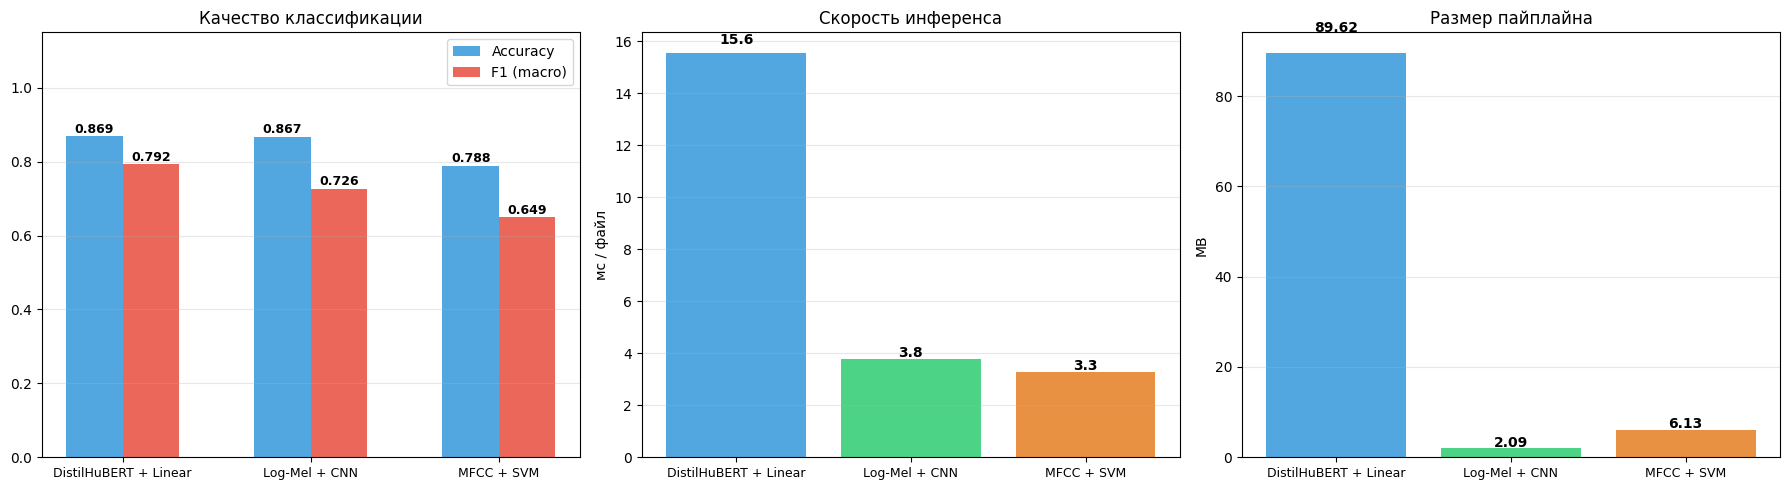

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models = df["Модель"].tolist()
x = np.arange(len(models))
colors = ["#3498db", "#2ecc71", "#e67e22"]

# ── Качество ──
w = 0.3
b1 = axes[0].bar(x - w / 2, df["Accuracy"], w,
                  label="Accuracy", color="#3498db", alpha=0.85)
b2 = axes[0].bar(x + w / 2, df["F1 (macro)"], w,
                  label="F1 (macro)", color="#e74c3c", alpha=0.85)
axes[0].set_ylim(0, 1.15)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, fontsize=9)
axes[0].set_title("Качество классификации")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)
for b in list(b1) + list(b2):
    axes[0].text(
        b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
        f"{b.get_height():.3f}", ha="center", fontsize=9, fontweight="bold",
    )

# ── Скорость инференса ──
b3 = axes[1].bar(x, df["Инференс (мс/файл)"], color=colors, alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, fontsize=9)
axes[1].set_ylabel("мс / файл")
axes[1].set_title("Скорость инференса")
axes[1].grid(axis="y", alpha=0.3)
for b in b3:
    axes[1].text(
        b.get_x() + b.get_width() / 2, b.get_height() * 1.02,
        f"{b.get_height():.1f}", ha="center", fontsize=10, fontweight="bold",
    )

# ── Размер пайплайна ──
b4 = axes[2].bar(x, df["Пайплайн (MB)"], color=colors, alpha=0.85)
axes[2].set_xticks(x)
axes[2].set_xticklabels(models, fontsize=9)
axes[2].set_ylabel("MB")
axes[2].set_title("Размер пайплайна")
axes[2].grid(axis="y", alpha=0.3)
for b in b4:
    axes[2].text(
        b.get_x() + b.get_width() / 2, b.get_height() * 1.05,
        f"{b.get_height():.2f}", ha="center", fontsize=10, fontweight="bold",
    )

plt.tight_layout()
plt.show()